# Tool Overhead Benchmark

This notebook benchmarks the time overhead of the FAST TCP pytest plugin.
It simulates a growing test suite with mutations (additions, modifications, deletions)
and measures the overhead of running pytest with `--fast-tcp` enabled.

Based on the setup from `snapshot_cache_growth.ipynb`, this notebook:
- Generates test files
- Mutates them over iterations
- Runs pytest with `--fast-tcp --fast-tcp-debug` to measure overhead
- Plots the results

In [1]:
from __future__ import annotations

import json
import math
import os
import random
import re
import shutil
import subprocess
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path("..").resolve()
RESEARCH_ROOT = Path(".").resolve()
PLAYGROUND_ROOT = RESEARCH_ROOT / "tool_overhead_playground"
TEST_DIR = PLAYGROUND_ROOT / "tests"

# Configuration
BASE_TEST_COUNT = 10  # Start with 10 test files
TESTS_PER_FILE = 5  # Number of test functions per file
ITERATIONS = 20  # Number of mutation iterations
ADD_RANGE: Tuple[int, int] = (1, 3)  # Add 1-3 tests per iteration
MODIFY_RANGE: Tuple[int, int] = (2, 5)  # Modify 2-5 tests per iteration
DELETE_RANGE: Tuple[int, int] = (0, 2)  # Delete 0-2 tests per iteration

print(f"Project root: {PROJECT_ROOT}")
print(f"Playground root: {PLAYGROUND_ROOT}")
print(f"Base test count: {BASE_TEST_COUNT}, tests per file: {TESTS_PER_FILE}")
print(f"Iterations configured: {ITERATIONS}")

Project root: /Users/tiagol./Documents/FAST
Playground root: /Users/tiagol./Documents/FAST/research/tool_overhead_playground
Base test count: 10, tests per file: 5
Iterations configured: 20


In [2]:
random.seed(42)

@dataclass
class BenchmarkRecord:
    iteration: int
    tag: str
    num_test_files: int
    num_test_functions: int
    files_added: int
    files_modified: int
    files_deleted: int
    partition_time: float
    prep_time: float
    prio_time: float
    total_time: float
    pytest_duration: float  # Total pytest execution time


def ensure_playground_clean() -> None:
    if PLAYGROUND_ROOT.exists():
        shutil.rmtree(PLAYGROUND_ROOT)
    TEST_DIR.mkdir(parents=True, exist_ok=True)
    # setup fast-tcp by calling fast-tcp init pytest
    subprocess.run(
        ["fast-tcp", "init", "pytest"],
        cwd=PLAYGROUND_ROOT,
        check=True,
    )


def generate_test_content(file_idx: int, num_tests: int) -> str:
    lines = [
        f"\"\"\"Test module {file_idx}.\"\"\"",
        "import random",
        "",
    ]
    for i in range(num_tests):
        lines.extend(
            [
                f"def test_function_{file_idx}_{i}():",
                f"    assert random.choice([True, True, True, False])",
                "",
            ]
        )
    return "\n".join(lines)


def count_test_functions(test_dir: Path) -> int:
    count = 0
    for test_file in test_dir.glob("test_*.py"):
        content = test_file.read_text()
        count += content.count("def test_")
    return count


def seed_tests() -> None:
    for idx in range(BASE_TEST_COUNT):
        test_file = TEST_DIR / f"test_mod_{idx:04d}.py"
        test_file.write_text(generate_test_content(idx, TESTS_PER_FILE))


def mutate_tests(iteration: int) -> Dict[str, int]:
    existing_files = sorted(TEST_DIR.glob("test_*.py"))
    stats = {"added": 0, "modified": 0, "deleted": 0}

    # Add new files
    num_add = random.randint(*ADD_RANGE)
    if existing_files:
        max_idx = max(
            int(f.stem.split("_")[-1]) for f in existing_files if f.stem.split("_")[-1].isdigit()
        )
    else:
        max_idx = -1
    for i in range(num_add):
        new_idx = max_idx + i + 1
        test_file = TEST_DIR / f"test_mod_{new_idx:04d}.py"
        test_file.write_text(generate_test_content(new_idx, TESTS_PER_FILE))
        stats["added"] += 1

    # Refresh file list
    existing_files = sorted(TEST_DIR.glob("test_*.py"))

    # Modify some files
    num_modify = min(random.randint(*MODIFY_RANGE), len(existing_files))
    for test_file in random.sample(existing_files, num_modify):
        idx = int(test_file.stem.split("_")[-1])
        # Add a comment to modify the file
        content = test_file.read_text()
        modified = content.replace(
            f"Test module {idx}",
            f"Test module {idx} (modified iter {iteration})",
        )
        test_file.write_text(modified)
        stats["modified"] += 1

    # Delete some files
    num_delete = min(random.randint(*DELETE_RANGE), len(existing_files))
    if num_delete > 0:
        for test_file in random.sample(existing_files, num_delete):
            test_file.unlink()
            stats["deleted"] += 1

    return stats


def run_pytest_with_fast_tcp() -> Tuple[float, float, float, float, float]:
    """Run pytest with FAST TCP and parse timing output."""
    cmd = [
        "pytest",
        str(TEST_DIR),
        "--fast-tcp",
        "--fast-tcp-debug",
        "-q",  # Quiet mode
        "--tb=no",  # No traceback
    ]

    start_time = time.perf_counter()
    result = subprocess.run(
        cmd,
        cwd=PLAYGROUND_ROOT,
        capture_output=True,
        text=True,
        timeout=60,
    )
    total_duration = time.perf_counter() - start_time

    # Parse debug output
    output = result.stdout + result.stderr
    partition_time = 0.0
    prep_time = 0.0
    prio_time = 0.0
    total_fast_time = 0.0

    for line in output.split("\n"):
        if "Partition time:" in line:
            partition_time = float(re.search(r"([0-9.]+)s", line).group(1))
        elif "Preparation time:" in line:
            prep_time = float(re.search(r"([0-9.]+)s", line).group(1))
        elif "Prioritization time:" in line:
            prio_time = float(re.search(r"([0-9.]+)s", line).group(1))
        elif "Total FAST TCP time:" in line:
            total_fast_time = float(re.search(r"([0-9.]+)s", line).group(1))

    return partition_time, prep_time, prio_time, total_fast_time, total_duration

In [3]:
# Initialize playground
ensure_playground_clean()
seed_tests()
records: List[BenchmarkRecord] = []

# Baseline measurement
partition, prep, prio, total_fast, duration = run_pytest_with_fast_tcp()
baseline = BenchmarkRecord(
    iteration=0,
    tag="baseline",
    num_test_files=BASE_TEST_COUNT,
    num_test_functions=count_test_functions(TEST_DIR),
    files_added=0,
    files_modified=0,
    files_deleted=0,
    partition_time=partition,
    prep_time=prep,
    prio_time=prio,
    total_time=total_fast,
    pytest_duration=duration,
)
records.append(baseline)
print(
    f"Baseline: {baseline.num_test_files} files, {baseline.num_test_functions} tests, "
    f"total overhead: {baseline.total_time:.4f}s"
)

Created /Users/tiagol./Documents/FAST/research/tool_overhead_playground/pytest.ini
Done. Run: pytest
Baseline: 10 files, 50 tests, total overhead: 1.5395s


In [4]:
# Run iterations
for iteration in range(1, ITERATIONS + 1):
    mut_stats = mutate_tests(iteration)
    partition, prep, prio, total_fast, duration = run_pytest_with_fast_tcp()

    num_files = len(list(TEST_DIR.glob("test_*.py")))
    num_funcs = count_test_functions(TEST_DIR)

    record = BenchmarkRecord(
        iteration=iteration,
        tag=f"iter-{iteration}",
        num_test_files=num_files,
        num_test_functions=num_funcs,
        files_added=mut_stats["added"],
        files_modified=mut_stats["modified"],
        files_deleted=mut_stats["deleted"],
        partition_time=partition,
        prep_time=prep,
        prio_time=prio,
        total_time=total_fast,
        pytest_duration=duration,
    )
    records.append(record)

    print(
        f"iter-{iteration:2d} | files={num_files:3d} | tests={num_funcs:3d} | "
        f"+{mut_stats['added']:1d} ~{mut_stats['modified']:1d} -{mut_stats['deleted']:1d} | "
        f"overhead={total_fast:.4f}s | duration={duration:.4f}s"
    )

print(f"Iterations completed. Total records: {len(records)}")

iter- 1 | files= 12 | tests= 60 | +3 ~2 -1 | overhead=1.2844s | duration=1.6709s
iter- 2 | files= 11 | tests= 55 | +1 ~3 -2 | overhead=1.2991s | duration=1.6738s
iter- 3 | files= 12 | tests= 60 | +3 ~5 -2 | overhead=1.3199s | duration=1.6761s
iter- 4 | files= 13 | tests= 65 | +3 ~3 -2 | overhead=1.3507s | duration=1.7005s
iter- 5 | files= 13 | tests= 65 | +2 ~4 -2 | overhead=1.3494s | duration=1.6789s
iter- 6 | files= 15 | tests= 75 | +2 ~3 -0 | overhead=1.4530s | duration=1.7892s
iter- 7 | files= 15 | tests= 75 | +1 ~5 -1 | overhead=1.4362s | duration=1.7970s
iter- 8 | files= 17 | tests= 85 | +3 ~5 -1 | overhead=1.4520s | duration=1.7815s
iter- 9 | files= 19 | tests= 95 | +3 ~3 -1 | overhead=1.4889s | duration=1.8094s
iter-10 | files= 19 | tests= 95 | +1 ~2 -1 | overhead=1.4787s | duration=1.8023s
iter-11 | files= 18 | tests= 90 | +1 ~4 -2 | overhead=1.4580s | duration=1.7923s
iter-12 | files= 20 | tests=100 | +3 ~3 -1 | overhead=1.5175s | duration=1.8455s
iter-13 | files= 23 | tests=

In [5]:
# Create DataFrame
df = pd.DataFrame([r.__dict__ for r in records])

# Summary statistics
summary_md = f"""
**Benchmark Summary**

- Test files: {df['num_test_files'].min()} → {df['num_test_files'].max()} (Δ {df['num_test_files'].max() - df['num_test_files'].min()})
- Test functions: {df['num_test_functions'].min()} → {df['num_test_functions'].max()} (Δ {df['num_test_functions'].max() - df['num_test_functions'].min()})
- Total overhead: {df['total_time'].min():.4f}s → {df['total_time'].max():.4f}s
- Avg preparation time: {df['prep_time'].mean():.4f}s
- Avg prioritization time: {df['prio_time'].mean():.4f}s
- Iterations sampled: {len(df)}
"""

display(Markdown(summary_md))

# Show last 10 iterations
display(Markdown("### Recent Iterations"))
display(
    df[
        [
            "iteration",
            "num_test_files",
            "num_test_functions",
            "partition_time",
            "prep_time",
            "prio_time",
            "total_time",
            "pytest_duration",
        ]
    ]
    .tail(10)
    .round(4)
)


**Benchmark Summary**

- Test files: 10 → 28 (Δ 18)
- Test functions: 50 → 140 (Δ 90)
- Total overhead: 1.2844s → 1.7708s
- Avg preparation time: 0.0291s
- Avg prioritization time: 0.0086s
- Iterations sampled: 21


### Recent Iterations

,iteration,num_test_files,num_test_functions,partition_time,prep_time,prio_time,total_time,pytest_duration
11,11,18,90,0.0001,0.0535,0.0070,1.4580,1.7923
12,12,20,100,0.0001,0.0239,0.0084,1.5175,1.8455
13,13,23,115,0.0001,0.0293,0.0120,1.5718,1.8966
14,14,22,110,0.0001,0.0321,0.0096,1.6171,1.9442
15,15,23,115,0.0001,0.0311,0.0108,1.7488,2.0853
16,16,23,115,0.0001,0.0290,0.0098,1.5930,1.9224
17,17,24,120,0.0001,0.0295,0.0104,1.6289,1.9717
18,18,26,130,0.0001,0.0347,0.0094,1.7708,2.1141
19,19,26,130,0.0001,0.0318,0.0116,1.6420,2.0101
20,20,28,140,0.0001,0.0345,0.0137,1.7165,2.0808


### Overhead Analysis Graphs

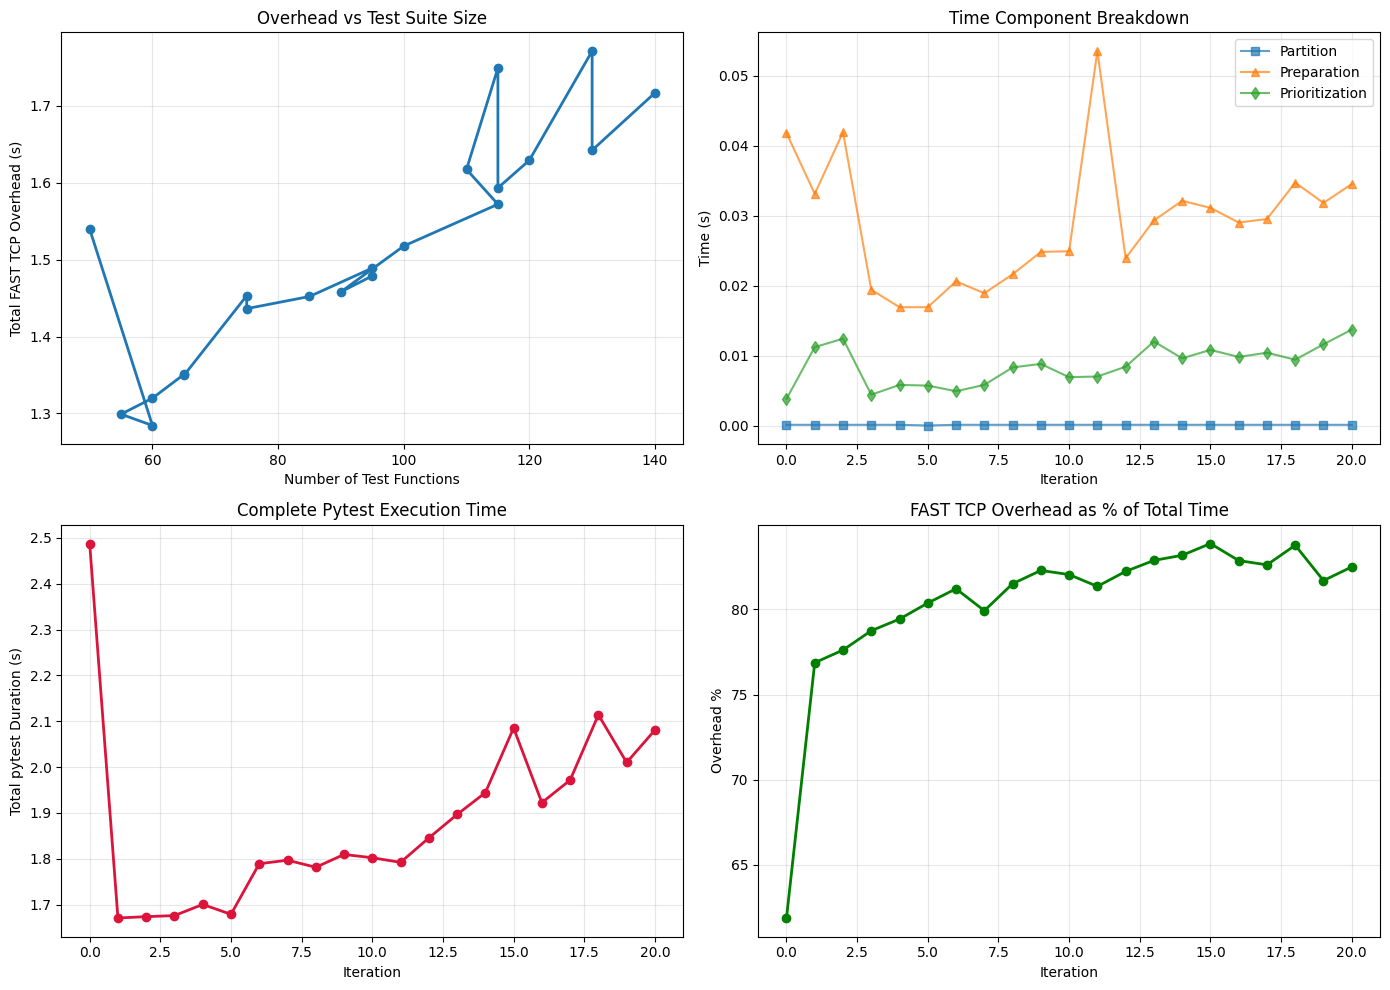

In [6]:
# Create visualizations
display(Markdown("### Overhead Analysis Graphs"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total overhead vs number of tests
axes[0, 0].plot(df["num_test_functions"], df["total_time"], marker="o", linewidth=2)
axes[0, 0].set_xlabel("Number of Test Functions")
axes[0, 0].set_ylabel("Total FAST TCP Overhead (s)")
axes[0, 0].set_title("Overhead vs Test Suite Size")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Breakdown of time components
axes[0, 1].plot(df["iteration"], df["partition_time"], marker="s", label="Partition", alpha=0.7)
axes[0, 1].plot(df["iteration"], df["prep_time"], marker="^", label="Preparation", alpha=0.7)
axes[0, 1].plot(df["iteration"], df["prio_time"], marker="d", label="Prioritization", alpha=0.7)
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Time (s)")
axes[0, 1].set_title("Time Component Breakdown")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Total pytest duration
axes[1, 0].plot(df["iteration"], df["pytest_duration"], marker="o", color="crimson", linewidth=2)
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Total pytest Duration (s)")
axes[1, 0].set_title("Complete Pytest Execution Time")
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Overhead percentage
df["overhead_pct"] = (df["total_time"] / df["pytest_duration"]) * 100
axes[1, 1].plot(df["iteration"], df["overhead_pct"], marker="o", color="green", linewidth=2)
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Overhead %")
axes[1, 1].set_title("FAST TCP Overhead as % of Total Time")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Churn Impact Analysis

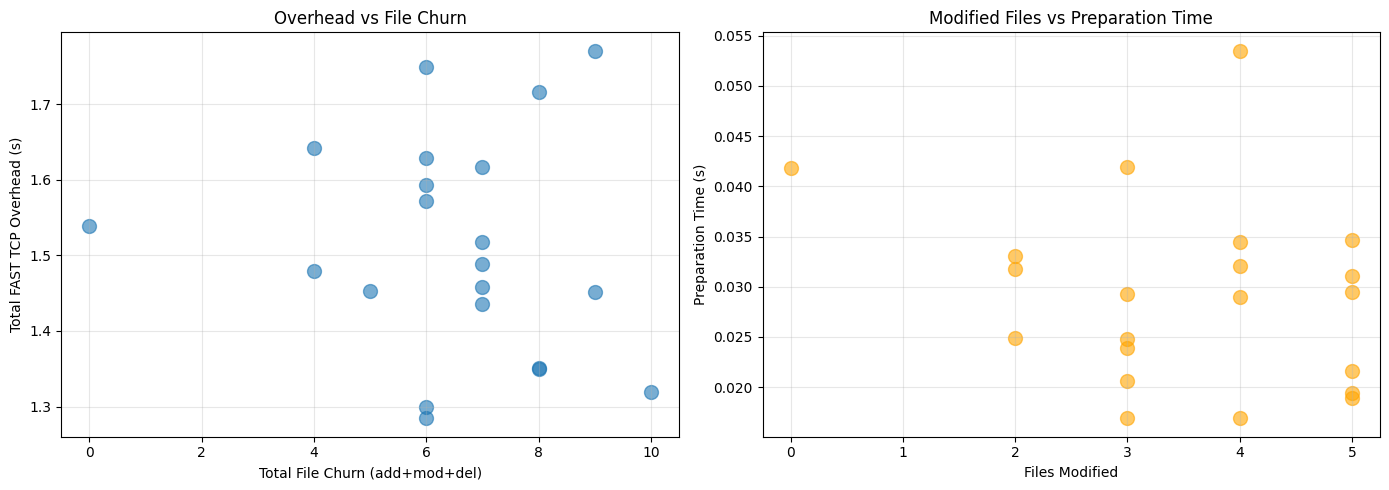

In [7]:
# Additional analysis: Relationship with churn
display(Markdown("### Churn Impact Analysis"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total churn (adds + mods + dels)
df["total_churn"] = df["files_added"] + df["files_modified"] + df["files_deleted"]

# Scatter: overhead vs churn
axes[0].scatter(df["total_churn"], df["total_time"], alpha=0.6, s=100)
axes[0].set_xlabel("Total File Churn (add+mod+del)")
axes[0].set_ylabel("Total FAST TCP Overhead (s)")
axes[0].set_title("Overhead vs File Churn")
axes[0].grid(True, alpha=0.3)

# Modification vs preparation time
axes[1].scatter(df["files_modified"], df["prep_time"], alpha=0.6, s=100, color="orange")
axes[1].set_xlabel("Files Modified")
axes[1].set_ylabel("Preparation Time (s)")
axes[1].set_title("Modified Files vs Preparation Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Key findings
display(Markdown("### Key Findings"))

findings = f"""
1. **Average Overhead**: {df['total_time'].mean():.4f}s per pytest run
2. **Overhead Range**: {df['total_time'].min():.4f}s - {df['total_time'].max():.4f}s
3. **Avg Overhead %**: {df['overhead_pct'].mean():.2f}% of total pytest time
4. **Preparation dominates**: Avg prep={df['prep_time'].mean():.4f}s vs prio={df['prio_time'].mean():.4f}s
5. **Scalability**: With {df['num_test_functions'].max()} tests, overhead is {df.iloc[-1]['total_time']:.4f}s

The FAST TCP plugin adds approximately **{df['total_time'].mean():.4f} seconds** of overhead
to prioritize tests, which is about **{df['overhead_pct'].mean():.2f}%** of the total pytest execution time.
"""

display(Markdown(findings))

### Key Findings


1. **Average Overhead**: 1.5103s per pytest run
2. **Overhead Range**: 1.2844s - 1.7708s
3. **Avg Overhead %**: 80.42% of total pytest time
4. **Preparation dominates**: Avg prep=0.0291s vs prio=0.0086s
5. **Scalability**: With 140 tests, overhead is 1.7165s

The FAST TCP plugin adds approximately **1.5103 seconds** of overhead
to prioritize tests, which is about **80.42%** of the total pytest execution time.
